# NT_V3 Concordance Analysis — Plot-by-Plot Notebook

Each section defines a plot function, runs a **single representative call** with explicit parameters, then loops over all subsets/modes.



---
## Cell 1: Imports, Config, Helpers

Constants, subset definitions, save utilities, and shared statistical functions used by all plot cells.

creating `merged` from LLM variant results with columns: `concordance`, `signal_category`, `MLM_category`, `primary_signal_mechanism`, `rationale_mechanism`, `variant_type`, and optionally score columns (`LLR`, `GPN-MSA`, `CADD`, etc.).

INPUTS:
- snps_deltas, indels_deltas: files with deltas and variant IDs
- snps, indels: LLM judgment results

In [ ]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Dict, Optional, List, Tuple, Union
from pathlib import Path

# ── Orders & colors ──────────────────────────────────────────────────
# signal_order / mlm_order: ordinal strength bins assigned by the LLM judge
# conc_order: concordance levels between NT delta signal and ClinVar rationale
DEFAULT_ORDER = ["ABSENT", "WEAK", "MODERATE", "STRONG"]
DEFAULT_CONC_ORDER = ["DISCORDANT", "PARTIAL", "CONCORDANT", "NOT_APPLICABLE"]
CONC_COLORS = {
    "CONCORDANT": "#2ecc71", "PARTIAL": "#f39c12",
    "DISCORDANT": "#e74c3c", "NOT_APPLICABLE": "#95a5a6",
}

# Score columns: conservation / functional scores from BW annotation pipeline
# LLR = NT_V3 log-likelihood ratio (delta); others from bigWig tracks
DEFAULT_SCORE_COLS = [
    "LLR", "GPN-MSA", "CADD", "phyloP-100v",
    "phyloP-241m", "phastCons-100v", "ESM-1b", "NT", "HyenaDNA",
]


# ── Subset definitions (used by every plot cell) ─────────────────────
# variant_type column comes from ClinVar VCF parsing (snp / indel)
SUBSETS = {
    "ALL":   lambda d: pd.Series(True, index=d.index),
    "SNP":   lambda d: d["variant_type"].eq("snp"),
    "INDEL": lambda d: d["variant_type"].eq("indel"),
}

# ── Output directory ─────────────────────────────────────────────────
REPORT_DIR = Path("ntv3_report")
DPI = 200
FMT = "png"

def _savefig(fig, path):
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(p), dpi=DPI, bbox_inches="tight", facecolor="white")

def _savedf(obj, path):
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj.to_csv(str(p))
    elif isinstance(obj, dict):
        ct = obj.get("crosstab")
        if ct is not None: ct.to_csv(str(p).replace(".csv","_crosstab.csv"))
        pd.Series({k:v for k,v in obj.items() if k!="crosstab"}).to_csv(
            str(p).replace(".csv","_stats.csv"))

# ── Shared stat helpers ──────────────────────────────────────────────
def _as_ordered_cat(s, order):
    return pd.Categorical(s, categories=order, ordered=True)

def _prep_df(df, concord_col, signal_col, mlm_col,
             signal_order, mlm_order, conc_order):
    out = df.copy()
    for col, order in [(signal_col, signal_order),
                       (mlm_col, mlm_order),
                       (concord_col, conc_order)]:
        out[col] = out[col].astype(str).str.strip().str.upper()
        out[col] = _as_ordered_cat(out[col], order)
    return out

def _safe_crosstab(row_s, col_s, row_order, col_order):
    tmp = pd.DataFrame({"row": row_s.values, "col": col_s.values})
    tmp["row"] = tmp["row"].astype(str).str.strip().str.upper()
    tmp["col"] = tmp["col"].astype(str).str.strip().str.upper()
    ct = pd.crosstab(tmp["row"], tmp["col"], dropna=False)
    ct.index = ct.index.astype(str); ct.columns = ct.columns.astype(str)
    if not ct.index.is_unique:  ct = ct.groupby(level=0).sum()
    if not ct.columns.is_unique: ct = ct.T.groupby(level=0).sum().T
    return ct.reindex(index=row_order, columns=col_order, fill_value=0)

def _ordinal_encode(s, order):
    return s.map({k:i for i,k in enumerate(order)}).astype("float")

def _spearman_rho(x, y):
    if len(x) < 3: return np.nan
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    if np.nanstd(rx)==0 or np.nanstd(ry)==0: return np.nan
    return float(np.corrcoef(rx, ry)[0, 1])

def _cramers_v_from_crosstab(ct):
    obs = ct.to_numpy(); n = obs.sum()
    if n == 0: return np.nan
    exp = obs.sum(1, keepdims=True) @ obs.sum(0, keepdims=True) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - exp)**2 / exp)
    r, k = obs.shape; denom = n * (min(r-1, k-1))
    return np.nan if denom <= 0 else float(np.sqrt(chi2 / denom))

print("Helpers loaded.")

# delta files with variants IDs
snps_deltas = pd.read_parquet("parquet/annotated_snps_signaled.parquet")
indels_deltas = pd.read_parquet("parquet/clinvar_indel_deltas.parquet")
indels_deltas.rename(columns={"variant_id":"#VariationID"}, inplace=True)

# loading LLM results
snps = pd.read_csv("parquet/snp_evaluation_results_v2.csv")
indels = pd.read_csv("parquet/indel_evaluation_results_v2.csv")

# annotating for concatenation
snps["variant_type"] = "snp"
indels["variant_type"] = "indel"
variants = pd.concat([snps, indels])
variants

# --- MERGE snps and indels
cols_from_deltas = DEFAULT_SCORE_COLS + ["#VariationID"]
merged = pd.merge(
    variants,
    snps_deltas[cols_from_deltas],
    on="#VariationID",
    how="left"
)

# merge indel LLR under a different name
merged = pd.merge(
    merged,
    indels_deltas[["#VariationID", "LLR"]].rename(columns={"LLR": "LLR_indel"}),
    on="#VariationID",
    how="left"
)

# fill SNP LLR NaNs with indel LLR
merged["LLR"] = merged["LLR"].fillna(merged["LLR_indel"])

# drop helper column
merged = merged.drop(columns=["LLR_indel"])


Helpers loaded.


---
## Cell 2: Mechanism Canonicalization

Regex-based bucketing of free-text mechanism labels into standardized categories.

- **Primary mechanism**: what the NT model signal suggests (MLM / splice / truncation / etc.)
- **Rationale mechanism**: what ClinVar reviewers cited as the pathogenic mechanism

Applied in-place to `merged` — run once before all plot cells.

In [ ]:
# ── Primary mechanism canonicalizer ───────────────────────────────────

def build_primary_mechanism_canonicalizer(
    merge_mlm_like=True,
    mlm_bucket_name="MLM / Sequence-constraint signal",
    model_favors_bucket_name="Model favors variant",
):
    CANON = {
        model_favors_bucket_name: [
            r"\bmodel favou?rs variant\b", r"\bmodel favou?rs the variant\b"],
        "Benign / Neutral / None": [
            r"\bnone detected\b", r"\bnone identified\b", r"\bno mechanism detected\b",
            r"\bneutral\b", r"\bbenign\b", r"\btolerated\b",
            r"\bsilent\b", r"\bsynonymous\b"],
        "Uncertain / Unknown": [
            r"\bunknown\b", r"\buncertain\b", r"\bundetermined\b",
            r"\binconclusive\b", r"\bunclear\b", r"\bna\b"],
        "Pharmacogenomic": [r"\bpharmacogen", r"\bdrug response\b", r"\bpharmacogenetic\b"],
        "Splicing": [
            r"\bsplice\b", r"\bsplicing\b", r"\bdonor\b", r"\bacceptor\b",
            r"\bexon skipping\b", r"\bintron retention\b", r"\bcryptic splice\b",
            r"\bpseudoexon\b", r"\bexon[- ]intron boundary\b",
            r"\bexon\b", r"\bintron\b"],
        "Start codon / Initiation / ORF": [
            r"\bstart codon\b", r"\bstart[- ]?loss\b",
            r"\binitiation\b", r"\btranslation initiation\b",
            r"\binitiator\b", r"\borf\b"],
        "Nonsense / Truncation / NMD": [
            r"\bnonsense\b", r"\bstop[- ]?gain\b", r"\bpremature stop\b",
            r"\btruncat", r"\bnmd\b", r"\btermination codon\b"],
        "Stop-loss / Protein extension": [
            r"\bstop[- ]?loss\b", r"\bprotein extension\b"],
        "Regulatory / Expression": [
            r"\bregulatory\b", r"\bexpression\b", r"\btranscription\b",
            r"\bcage\b", r"\b3'\s*utr\b", r"\b5'\s*utr\b",
            r"\bdownregulat", r"\bupregulat"],
        "3' UTR": [r"\b3'\s*utr\b"], "5' UTR": [r"\b5'\s*utr\b"],
        "UTR": [r"\butr\b"],
        mlm_bucket_name: [
            r"\bmlm\b", r"\bllr\b", r"\blogprob\b", r"\bprior\b", r"\bdelta\b",
            r"\bsequence plausibility\b", r"\bsequence preference\b",
            r"\bsequence disruption\b", r"\bsequence context\b",
            r"\bconstraint\b", r"\bintoler", r"\bconservation\b",
            r"\bevolutionary\b", r"\bconserved\b",
            r"\bmissense\b", r"\bamino acid\b",
            r"\bprotein\b", r"\bprotein[- ]level\b", r"\bprotein[- ]coding\b",
            r"\bcoding sequence\b", r"\bcoding\b",
            r"\bprotein function\b", r"\bprotein functional\b",
            r"\bprotein structural\b",
            r"\bnon[- ]?synonymous\b", r"\bcoding disruption\b"],
    }
    PRIORITY = [
        model_favors_bucket_name, "Benign / Neutral / None", "Uncertain / Unknown",
        "Pharmacogenomic", "Splicing", "Start codon / Initiation / ORF",
        "Nonsense / Truncation / NMD", "Stop-loss / Protein extension",
        "Regulatory / Expression", mlm_bucket_name,
    ]
    if not merge_mlm_like:
        CANON[mlm_bucket_name] = [
            r"\bmlm\b", r"\bllr\b", r"\blogprob\b",
            r"\bsequence plausibility\b", r"\bsequence preference\b"]
    CANON_RE = {k: [re.compile(p, re.I) for p in pats] for k, pats in CANON.items()}
    EFFECT_GUARD_RE = re.compile(
        r"\b(model favou?rs variant|non[- ]?synonymous|coding disruption|"
        r"missense|amino acid|protein|coding|mlm|llr|logprob|prior|delta|"
        r"constraint|conservation|conserved|evolutionary|intoler|"
        r"splice|splicing|donor|acceptor|nmd|nonsense|"
        r"stop[- ]?gain|stop[- ]?loss|truncat)\b", re.I)

    def _canonicalize(label):
        if label is None or (isinstance(label, float) and pd.isna(label)):
            return "Uncertain / Unknown"
        s = str(label).strip()
        if not s: return "Uncertain / Unknown"
        s_norm = s.replace("_"," ").replace("|"," ").replace(","," ").lower()
        benign_hit = any(rx.search(s_norm) for rx in CANON_RE["Benign / Neutral / None"])
        if benign_hit and EFFECT_GUARD_RE.search(s_norm):
            for bucket in [b for b in PRIORITY if b != "Benign / Neutral / None"]:
                for rx in CANON_RE[bucket]:
                    if rx.search(s_norm): return bucket
            return "Other / Unclassified"
        for bucket in PRIORITY:
            for rx in CANON_RE[bucket]:
                if rx.search(s_norm): return bucket
        return "Other / Unclassified"
    return _canonicalize


# ── Rationale mechanism canonicalizer ────────────────────────────────

def build_rationale_mechanism_canonicalizer():
    CANON = {
        "Splicing": [
            r"\bsplice\b", r"\bsplicing\b", r"\bdonor\b", r"\bacceptor\b",
            r"\bexon skipping\b", r"\bintron retention\b", r"\bcryptic splice\b"],
        "Start codon / Initiation / ORF": [
            r"\bstart codon\b", r"\bstart[- ]?loss\b",
            r"\binitiation\b", r"\btranslation initiation\b", r"\borf\b"],
        "Nonsense / Truncation / NMD": [
            r"\bnonsense\b", r"\bstop[- ]?gain\b", r"\bpremature stop\b",
            r"\btruncat", r"\bnmd\b"],
        "Stop-loss / Protein extension": [
            r"\bstop[- ]?loss\b", r"\bprotein extension\b"],
        "Frameshift": [r"\bframeshift\b"],
        "Pharmacogenomic": [r"\bpharmacogen", r"\bdrug response\b"],
        "Regulatory / Transcriptional": [
            r"\bregulatory\b", r"\btranscription\b", r"\bcage\b",
            r"\bdownregulat", r"\bupregulat", r"\bexpression\b",
            r"\btranscriptional\b"],
        "3' UTR": [r"3'\s*utr"], "5' UTR": [r"5'\s*utr"],
        "UTR": [r"\butr\b"],
        "Missense / Protein function": [
            r"\bmissense\b", r"\bamino acid\b",
            r"\bprotein function\b", r"\bprotein structural\b",
            r"\bgain[- ]of[- ]function\b", r"\bloss[- ]of[- ]function\b",
            r"\bdominant[- ]negative\b"],
        "Sequence constraint / Conservation": [
            r"\bconstraint\b", r"\bconservation\b", r"\bconserved\b",
            r"\bevolutionary\b", r"\bintoler",
            r"\bsequence conservation\b", r"\bsequence constraint\b",
            r"\bprotein[- ]?level\b", r"\bprotein[- ]?coding\b",
            r"\bcoding sequence\b", r"\bcoding\b", r"\bsequence\b"],
        "Benign / Neutral / None": [
            r"\bnone\b", r"\bnone detected\b", r"\bneutral\b",
            r"\bbenign\b", r"\btolerated\b", r"\bsilent\b",
            r"\bsynonymous\b", r"\bminimal\b", r"\bno significant\b",
            r"\bno functional\b"],
        "Uncertain / Unknown": [
            r"\bunknown\b", r"\buncertain\b", r"\bundetermined\b",
            r"\binconclusive\b", r"\bunclear\b"],
    }
    PRIORITY = [
        "Splicing", "Start codon / Initiation / ORF",
        "Nonsense / Truncation / NMD", "Stop-loss / Protein extension",
        "Frameshift", "Pharmacogenomic", "Regulatory / Transcriptional",
        "3' UTR", "5' UTR", "UTR",
        "Missense / Protein function", "Sequence constraint / Conservation",
        "Benign / Neutral / None", "Uncertain / Unknown",
    ]
    CANON_RE = {k: [re.compile(p, re.I) for p in pats] for k, pats in CANON.items()}
    EFFECT_GUARD_RE = re.compile(
        r"\b(constraint|conservation|conserved|evolutionary|intoler|"
        r"splice|splicing|donor|acceptor|nmd|nonsense|truncat|"
        r"missense|amino acid|protein[- ]?function|protein[- ]?structural|"
        r"protein[- ]?coding|coding sequence|coding disruption|"
        r"regulatory|transcription|cage|"
        r"start codon|initiation|orf|frameshift)\b", re.I)
    _SOFT = (r"sequence|variant|effect|impact|change|variation|context"
             r"|perturbation|evolution|neutrality|non[- ]?functional"
             r"|disruption|no|functional|significant")
    NEUTRAL_DOM_RE = re.compile(
        r"^\s*(neutral|none|benign|minimal|no significant|no functional|sequence neutrality)"
        r"(\s*/\s*(neutral|none|minimal|no\s+\w+))?"
        r"(\s+(" + _SOFT + r"))*\s*$", re.I)

    def _canonicalize(label):
        if label is None or (isinstance(label, float) and pd.isna(label)):
            return "Uncertain / Unknown"
        s = str(label).strip()
        if not s: return "Uncertain / Unknown"
        s_norm = s.replace("_"," ").replace("|"," ").replace(","," ").lower()
        if NEUTRAL_DOM_RE.match(s_norm): return "Benign / Neutral / None"
        benign_hit = any(rx.search(s_norm) for rx in CANON_RE["Benign / Neutral / None"])
        if benign_hit and EFFECT_GUARD_RE.search(s_norm):
            for bucket in [b for b in PRIORITY if b != "Benign / Neutral / None"]:
                for rx in CANON_RE[bucket]:
                    if rx.search(s_norm): return bucket
            return "Other / Unclassified"
        for bucket in PRIORITY:
            for rx in CANON_RE[bucket]:
                if rx.search(s_norm): return bucket
        return "Other / Unclassified"
    return _canonicalize


# ── Apply canonicalization ───────────────────────────────────────────
primary_canon  = build_primary_mechanism_canonicalizer()
rationale_canon = build_rationale_mechanism_canonicalizer()

merged["primary_signal_mechanism_raw"]  = merged["primary_signal_mechanism"]
merged["rationale_mechanism_raw"]       = merged["rationale_mechanism"]
merged["primary_signal_mechanism"]      = merged["primary_signal_mechanism"].map(primary_canon)
merged["rationale_mechanism"]           = merged["rationale_mechanism"].map(rationale_canon)

print("Mechanisms canonicalized.")
print(merged["primary_signal_mechanism"].value_counts())

Mechanisms canonicalized.
primary_signal_mechanism
MLM / Sequence-constraint signal    10675
Start codon / Initiation / ORF       3780
Benign / Neutral / None              2838
Other / Unclassified                 2530
Regulatory / Expression              1406
Splicing                              521
Uncertain / Unknown                   297
Nonsense / Truncation / NMD            40
Name: count, dtype: int64


---
## Plot 1: Concordance Bars by Strength Axis

Grouped bar chart showing concordance-level fractions within each strength bin.

**Parameters to vary:**
- `group_col`: `"signal_category"` (NT delta signal strength) or `"MLM_category"` (MLM sequence-context strength)
- `normalize`: `True` → fractions (default), `False` → raw counts
- `group_order`: defaults to `DEFAULT_ORDER` = `[ABSENT, WEAK, MODERATE, STRONG]`
- `conc_order` / `conc_colors`: concordance levels and their colors

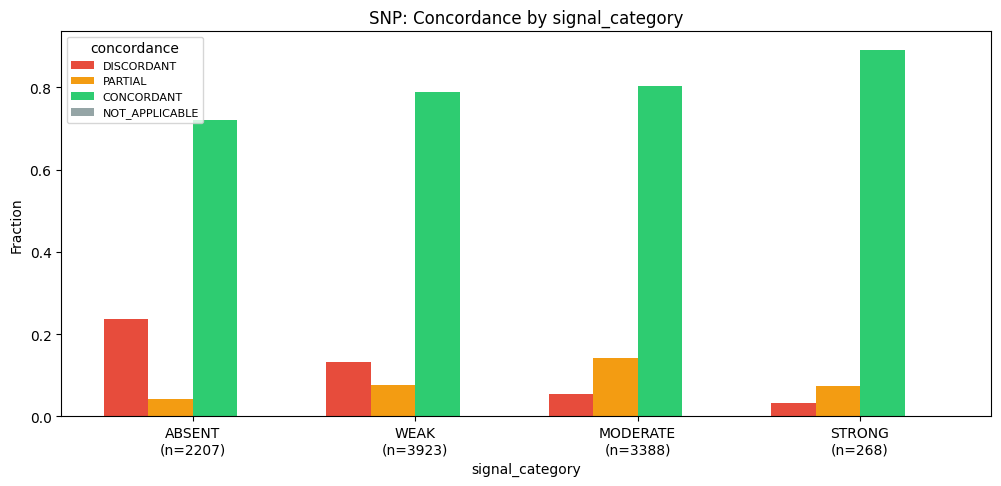

In [ ]:
def plot_concordance_bars(
    df, group_col="signal_category", concord_col="concordance",
    group_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    conc_colors=CONC_COLORS, normalize=True,
    figsize=(12, 5), title=None, ax=None,
):
    d = df.copy()
    d[group_col]   = d[group_col].astype(str).str.strip().str.upper()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()
    ct = _safe_crosstab(d[group_col], d[concord_col], group_order, conc_order)

    if normalize:
        plot_df = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        ylabel = "Fraction"
    else:
        plot_df = ct; ylabel = "Count"

    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    else: fig = ax.figure

    x = np.arange(len(group_order)); n_bars = len(conc_order)
    width = 0.8 / n_bars
    for i, conc in enumerate(conc_order):
        if conc not in plot_df.columns: continue
        ax.bar(x + i*width - 0.4 + width/2, plot_df[conc].values, width,
               label=conc, color=conc_colors.get(conc))

    row_totals = ct.sum(axis=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n(n={int(row_totals.get(g,0))})" for g in group_order])
    ax.set_ylabel(ylabel); ax.set_xlabel(group_col)
    ax.legend(title=concord_col, fontsize=8, loc="upper left")
    ax.set_title(title or f"Concordance by {group_col} (N={len(d)})"
                 + (" — normalized" if normalize else ""))
    return fig, ax, plot_df


# ── Single representative call: SNP subset, by signal_category ───────
# group_col options: "signal_category", "MLM_category"
# normalize options: True (fraction), False (raw count)
dsub_snp = merged.loc[SUBSETS["SNP"](merged)].copy()
fig, ax, df_out = plot_concordance_bars(
    dsub_snp,
    group_col="signal_category",      # try also: "MLM_category"
    normalize=True,                    # try also: False
    title="SNP: Concordance by signal_category",
)
plt.show()


# # ── Full loop: ALL / SNP / INDEL × both group axes ──────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     base = REPORT_DIR / subset_name / "1_concordance_by_strength"
#     for gcol in ["signal_category", "MLM_category"]:
#         fig, ax, df_out = plot_concordance_bars(
#             dsub, group_col=gcol,
#             title=f"{subset_name}: Concordance by {gcol}")
#         _savefig(fig, base / f"concordance_by_{gcol}.{FMT}")
#         _savedf(df_out, base / f"concordance_by_{gcol}.csv")
#         plt.show()

---
## Plot 2: Concordance Fraction Heatmaps

One heatmap per concordance level. Each cell = fraction of variants in that (signal_category × MLM_category) bin assigned this concordance.

**Parameters to vary:**
- `signal_order` / `mlm_order`: row/column bin ordering
- `conc_order`: which concordance panels to show
- `figsize_per`: size per panel (scales with number of panels)

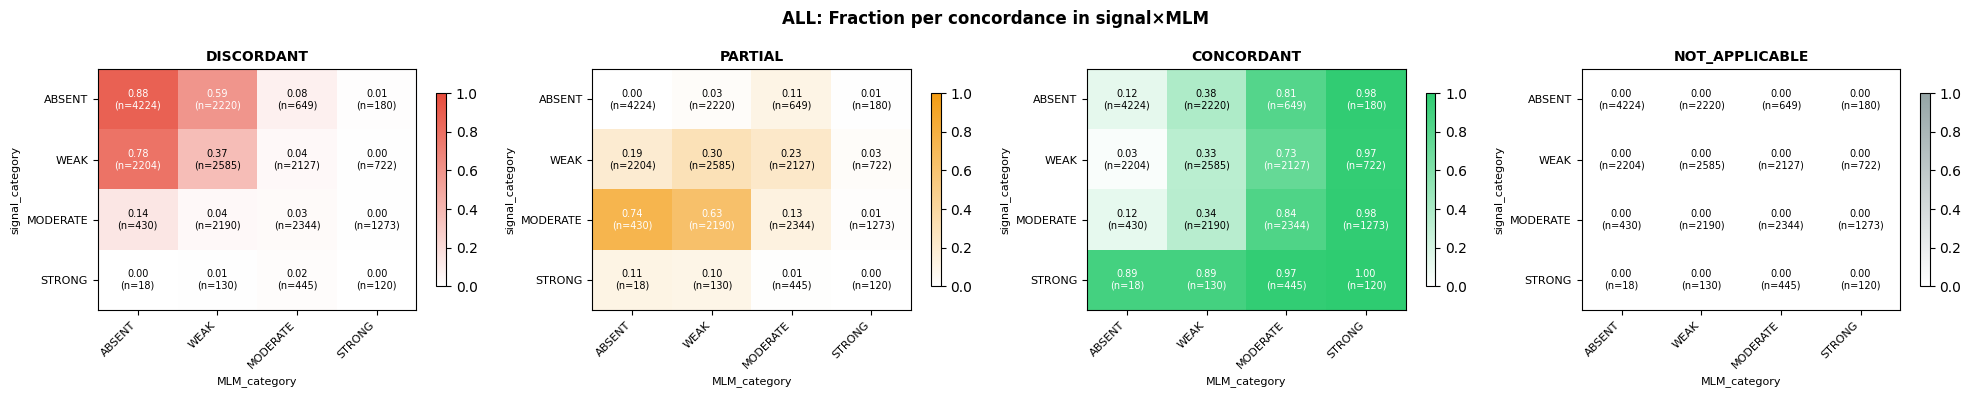

In [ ]:
def plot_concordance_heatmaps(
    df, concord_col="concordance", signal_col="signal_category",
    mlm_col="MLM_category", signal_order=DEFAULT_ORDER,
    mlm_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    figsize_per=(5, 4), suptitle=None,
):
    d = _prep_df(df, concord_col, signal_col, mlm_col,
                 signal_order, mlm_order, conc_order)
    counts = (d.groupby([signal_col, mlm_col, concord_col], observed=False)
              .size().unstack(concord_col, fill_value=0))
    idx = pd.MultiIndex.from_product([signal_order, mlm_order],
                                     names=[signal_col, mlm_col])
    counts = counts.reindex(idx, fill_value=0)
    denom = counts.sum(axis=1).replace(0, np.nan)

    n_conc = len(conc_order)
    fig, axes = plt.subplots(1, n_conc,
                             figsize=(figsize_per[0]*n_conc, figsize_per[1]))
    if n_conc == 1: axes = [axes]

    heat_tables = {}
    for k, conc_val in enumerate(conc_order):
        ax = axes[k]
        col_vals = counts.get(conc_val, pd.Series(0, index=counts.index))
        frac = (col_vals / denom).unstack(mlm_col).reindex(
            index=signal_order, columns=mlm_order).fillna(0)
        heat_tables[conc_val] = frac

        cmap = mcolors.LinearSegmentedColormap.from_list(
            f"cmap_{conc_val}",
            ["#ffffff", CONC_COLORS.get(conc_val, "#3498db")], N=256)
        im = ax.imshow(frac.to_numpy(), aspect="auto", cmap=cmap, vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks(np.arange(len(mlm_order)))
        ax.set_xticklabels(mlm_order, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(signal_order)))
        ax.set_yticklabels(signal_order, fontsize=8)
        ax.set_xlabel(mlm_col, fontsize=8); ax.set_ylabel(signal_col, fontsize=8)
        ax.set_title(conc_val, fontsize=10, fontweight="bold")

        cell_totals = counts.sum(axis=1).unstack(mlm_col).reindex(
            index=signal_order, columns=mlm_order).fillna(0)
        for i in range(frac.shape[0]):
            for j in range(frac.shape[1]):
                v = frac.iloc[i, j]; nt = int(cell_totals.iloc[i, j])
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}\n(n={nt})", ha="center", va="center",
                            fontsize=7, color="white" if v > 0.5 else "black")

    if suptitle: fig.suptitle(suptitle, fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig, axes, heat_tables


# ── Single representative call: ALL variants ─────────────────────────
# conc_order: show only a subset of panels, e.g. ["CONCORDANT", "DISCORDANT"]
# figsize_per: (width, height) per panel — (5,4) works for 4 panels
fig, axes, htables = plot_concordance_heatmaps(
    merged,
    suptitle="ALL: Fraction per concordance in signal×MLM",
)
plt.show()


# # ── Full loop ────────────────────────────────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     base = REPORT_DIR / subset_name / "2_concordance_heatmaps"
#     fig, axes, htables = plot_concordance_heatmaps(
#         dsub, suptitle=f"{subset_name}: Fraction per concordance in signal×MLM")
#     _savefig(fig, base / f"concordance_heatmaps.{FMT}")
#     for cv, tbl in htables.items():
#         _savedf(tbl, base / f"heatmap_{cv}.csv")
#     plt.show()

---
## Plot 3: Stacked Concordance Bars per (Signal × MLM) Cell

Each x-tick is one (signal_category, MLM_category) combination. The stacked bar shows concordance composition within that cell.

**Parameters to vary:**
- `per_cell`: `True` → proportions (default), `False` → raw counts
- `figsize`: `(14, 5)` default — widen for many x-ticks

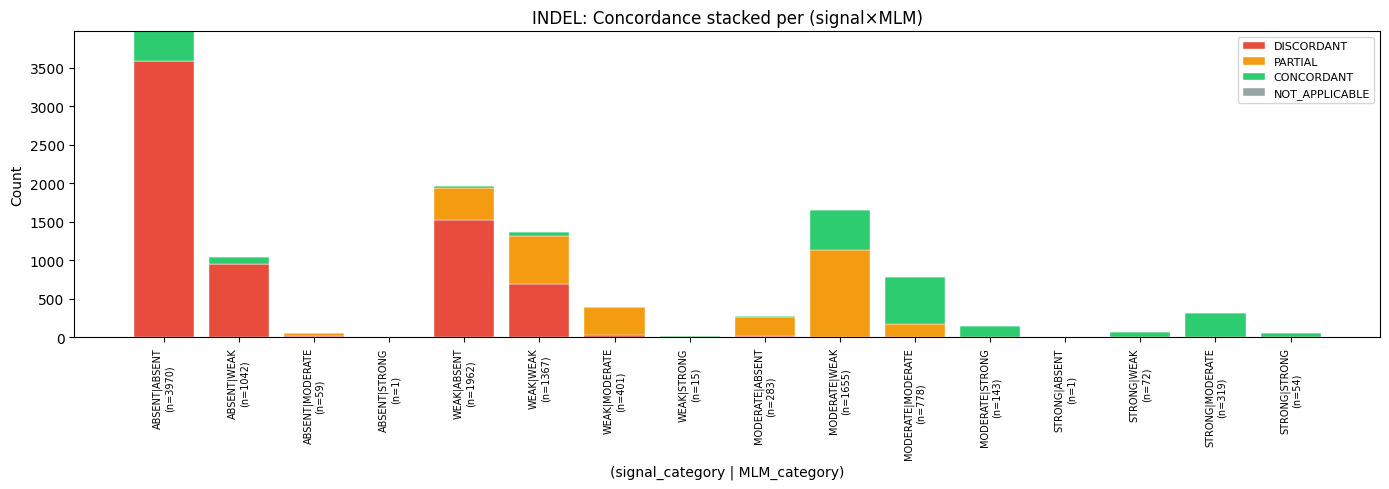

In [ ]:
def plot_concordance_stacked(
    df, concord_col="concordance", signal_col="signal_category",
    mlm_col="MLM_category", signal_order=DEFAULT_ORDER,
    mlm_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    conc_colors=CONC_COLORS, per_cell=True,
    figsize=(14, 5), title=None,
):
    d = _prep_df(df, concord_col, signal_col, mlm_col,
                 signal_order, mlm_order, conc_order)
    ct = (d.groupby([signal_col, mlm_col, concord_col], observed=False)
          .size().unstack(concord_col, fill_value=0))
    idx = pd.MultiIndex.from_product([signal_order, mlm_order],
                                     names=[signal_col, mlm_col])
    ct = ct.reindex(idx, fill_value=0)

    if per_cell:
        plot_df = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    else:
        plot_df = ct

    row_totals = ct.sum(axis=1)
    xlabels = [f"{s}|{m}\n(n={int(row_totals.get((s,m),0))})"
               for s, m in plot_df.index]
    x = np.arange(len(xlabels))

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(xlabels))
    for c in conc_order:
        if c not in plot_df.columns: continue
        vals = plot_df[c].to_numpy()
        ax.bar(x, vals, bottom=bottom, label=c,
               color=conc_colors.get(c), edgecolor="white", linewidth=0.3)
        bottom += vals

    ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=90, fontsize=7)
    ax.set_ylabel("Proportion" if per_cell else "Count")
    ax.set_xlabel(f"({signal_col} | {mlm_col})")
    ax.set_title(title or "Concordance composition per (signal × MLM) cell")
    ax.legend(fontsize=8); fig.tight_layout()
    return fig, ax, plot_df


# ── Single representative call: INDEL subset ────────────────────────
# per_cell options: True (proportion), False (raw count)
dsub_indel = merged.loc[SUBSETS["INDEL"](merged)].copy()
fig, ax, df_out = plot_concordance_stacked(
    dsub_indel,
    per_cell=False,                     # try also: False
    title="INDEL: Concordance stacked per (signal×MLM)",
)
plt.show()


# # ── Full loop ────────────────────────────────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     base = REPORT_DIR / subset_name / "3_concordance_stacked"
#     fig, ax, df_out = plot_concordance_stacked(
#         dsub, title=f"{subset_name}: Concordance stacked per (signal×MLM)")
#     _savefig(fig, base / f"concordance_stacked.{FMT}")
#     _savedf(df_out, base / "concordance_stacked.csv")
#     plt.show()

---
## Plot 4: Top Mechanism Bars per Concordance Value

Horizontal bar chart of the most frequent mechanism buckets within a given concordance level.

**Parameters to vary:**
- `mechanism_col`: `"rationale_mechanism"` (ClinVar-cited) or `"primary_signal_mechanism"` (NT-inferred)
- `concordance_value`: any of `CONCORDANT`, `DISCORDANT`, `PARTIAL`, `NOT_APPLICABLE`
- `top_k`: number of mechanism buckets to show (default 15)
- `normalize`: `True` → fractions, `False` → counts (default)

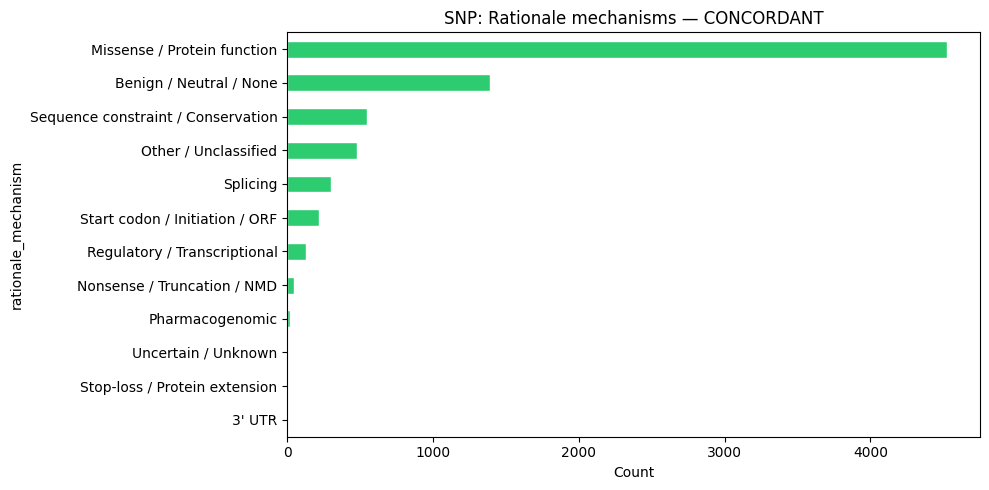

In [ ]:
def plot_mechanism_bars(
    df, concordance_value="CONCORDANT",
    mechanism_col="rationale_mechanism", concord_col="concordance",
    top_k=15, normalize=False, figsize=(10, 5), title=None, ax=None,
):
    d = df.copy()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()
    sub = d[d[concord_col] == concordance_value.upper()]
    counts = sub[mechanism_col].value_counts(dropna=False).head(top_k)
    if normalize:
        total = counts.sum()
        if total > 0: counts = counts / total
    n_total = len(sub)

    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    else: fig = ax.figure

    if counts.empty or counts.sum() == 0:
        ax.text(0.5, 0.5, f"No data for {concordance_value}",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=12, color="grey")
        ax.set_title(title or f"Top {top_k} mechanisms — {concordance_value} (n={n_total})")
        return fig, ax, counts

    color = CONC_COLORS.get(concordance_value.upper(), "#3498db")
    counts.iloc[::-1].plot.barh(ax=ax, color=color, edgecolor="white")
    ax.set_xlabel("Fraction" if normalize else "Count")
    ax.set_ylabel(mechanism_col)
    ax.set_title(title or f"Top {top_k} mechanisms — {concordance_value} (n={n_total})")
    fig.tight_layout()
    return fig, ax, counts


# ── Single representative call: SNP, CONCORDANT, rationale mechanism ─
# mechanism_col options: "rationale_mechanism", "primary_signal_mechanism"
# concordance_value options: "CONCORDANT", "DISCORDANT", "PARTIAL", "NOT_APPLICABLE"
# normalize options: True, False
dsub_snp = merged.loc[SUBSETS["SNP"](merged)].copy()
fig, ax, s_out = plot_mechanism_bars(
    dsub_snp,
    concordance_value="CONCORDANT",              # try: "DISCORDANT", "PARTIAL"
    mechanism_col="rationale_mechanism",          # try: "primary_signal_mechanism"
    top_k=15,                                    # try: 10, 20
    normalize=False,                             # try: True
    title="SNP: Rationale mechanisms — CONCORDANT",
)
plt.show()


# # ── Full loop: ALL/SNP/INDEL × rationale+primary × each conc level ──
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     for mech_type, mech_col in [("rationale", "rationale_mechanism"),
#                                  ("primary",  "primary_signal_mechanism")]:
#         for cv in DEFAULT_CONC_ORDER:
#             base = REPORT_DIR / subset_name / "4_mechanism_bars" / mech_type
#             fig, ax, s_out = plot_mechanism_bars(
#                 dsub, concordance_value=cv, mechanism_col=mech_col,
#                 title=f"{subset_name}: {mech_type.title()} mechanisms — {cv}")
#             _savefig(fig, base / f"{cv}.{FMT}")
#             _savedf(s_out, base / f"{cv}.csv")
#             plt.show()

---
## Plot 5: Correlation Summary (Spearman ρ & Cramér's V per Concordance)

For each concordance level, compute ordinal Spearman ρ and Cramér's V between signal_category and MLM_category. Shows whether signal and MLM strengths are associated differently across concordance strata.

**Parameters to vary:**
- `signal_order` / `mlm_order`: ordinal encoding order
- `conc_order`: which concordance levels to include

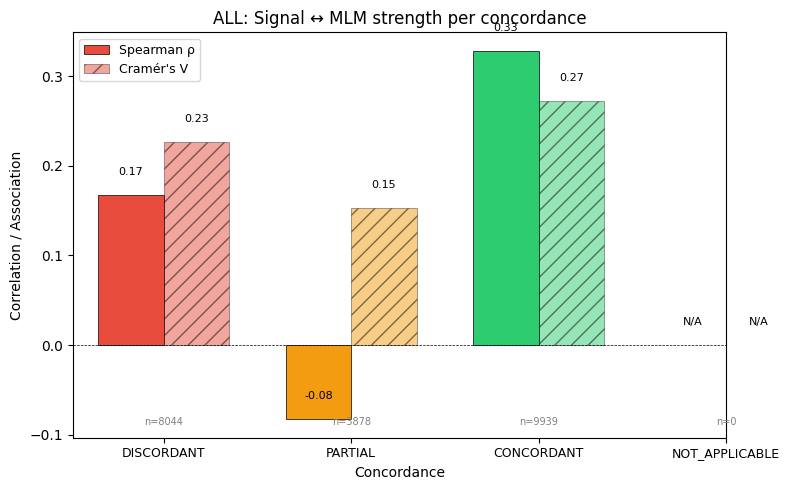

      concordance     n  spearman_rho  cramers_v
0      DISCORDANT  8044      0.167438   0.226959
1         PARTIAL  3878     -0.082753   0.153383
2      CONCORDANT  9939      0.328239   0.272477
3  NOT_APPLICABLE     0           NaN        NaN


In [ ]:
def plot_strength_correlation_summary(
    df, concord_col="concordance", signal_col="signal_category",
    mlm_col="MLM_category", signal_order=DEFAULT_ORDER,
    mlm_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    conc_colors=CONC_COLORS, figsize=(8, 5), title=None,
):
    d = df.copy()
    for col in [concord_col, signal_col, mlm_col]:
        d[col] = d[col].astype(str).str.strip().str.upper()

    rows = []
    for conc_val in conc_order:
        sub = d[d[concord_col] == conc_val]
        s_enc = _ordinal_encode(sub[signal_col], signal_order)
        m_enc = _ordinal_encode(sub[mlm_col], mlm_order)
        mask = s_enc.notna() & m_enc.notna(); n = int(mask.sum())
        rho = _spearman_rho(s_enc[mask].to_numpy(),
                            m_enc[mask].to_numpy()) if n >= 3 else np.nan
        ct = _safe_crosstab(sub[signal_col], sub[mlm_col],
                            signal_order, mlm_order)
        cv = _cramers_v_from_crosstab(ct)
        rows.append({"concordance": conc_val, "n": n,
                     "spearman_rho": rho, "cramers_v": cv})

    stats_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(conc_order)); width = 0.35
    rho_vals = stats_df["spearman_rho"].values
    cv_vals  = stats_df["cramers_v"].values
    bar_colors = [conc_colors.get(c, "#3498db") for c in conc_order]

    ax.bar(x - width/2, rho_vals, width, label="Spearman ρ",
           color=bar_colors, edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, cv_vals, width, label="Cramér's V",
           color=bar_colors, edgecolor="black", linewidth=0.5,
           alpha=0.5, hatch="//")

    for i, (r, v, n) in enumerate(zip(rho_vals, cv_vals, stats_df["n"])):
        r_s = f"{r:.2f}" if np.isfinite(r) else "N/A"
        v_s = f"{v:.2f}" if np.isfinite(v) else "N/A"
        ax.text(i - width/2, (r if np.isfinite(r) else 0) + 0.02,
                r_s, ha="center", va="bottom", fontsize=8)
        ax.text(i + width/2, (v if np.isfinite(v) else 0) + 0.02,
                v_s, ha="center", va="bottom", fontsize=8)
        ax.text(i, -0.08, f"n={n}", ha="center", va="top",
                fontsize=7, color="grey")

    ax.set_xticks(x); ax.set_xticklabels(conc_order, fontsize=9)
    ax.set_ylabel("Correlation / Association"); ax.set_xlabel("Concordance")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.legend(fontsize=9)
    ax.set_title(title or "Signal ↔ MLM strength association per concordance")
    fig.tight_layout()
    return fig, ax, stats_df


# ── Single representative call: ALL variants ─────────────────────────
# conc_order: subset to e.g. ["CONCORDANT","DISCORDANT"] to focus comparison
fig, ax, stats = plot_strength_correlation_summary(
    merged,
    title="ALL: Signal ↔ MLM strength per concordance",
)
plt.show()
print(stats)


# # ── Full loop ────────────────────────────────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     base = REPORT_DIR / subset_name / "5_correlation_summary"
#     fig, ax, stats = plot_strength_correlation_summary(
#         dsub, title=f"{subset_name}: Signal ↔ MLM strength per concordance")
#     _savefig(fig, base / f"correlation_summary.{FMT}")
#     _savedf(stats, base / "correlation_stats.csv")
#     plt.show()

---
## Plot 6: Concordance Breakdown per Mechanism Bucket

Stacked horizontal bar: for each mechanism, what fraction is CONCORDANT vs DISCORDANT vs PARTIAL vs N/A. Sorted by total count descending.

**Parameters to vary:**
- `mechanism_col`: `"rationale_mechanism"` or `"primary_signal_mechanism"`
- `top_k`: number of mechanism buckets (default 15)

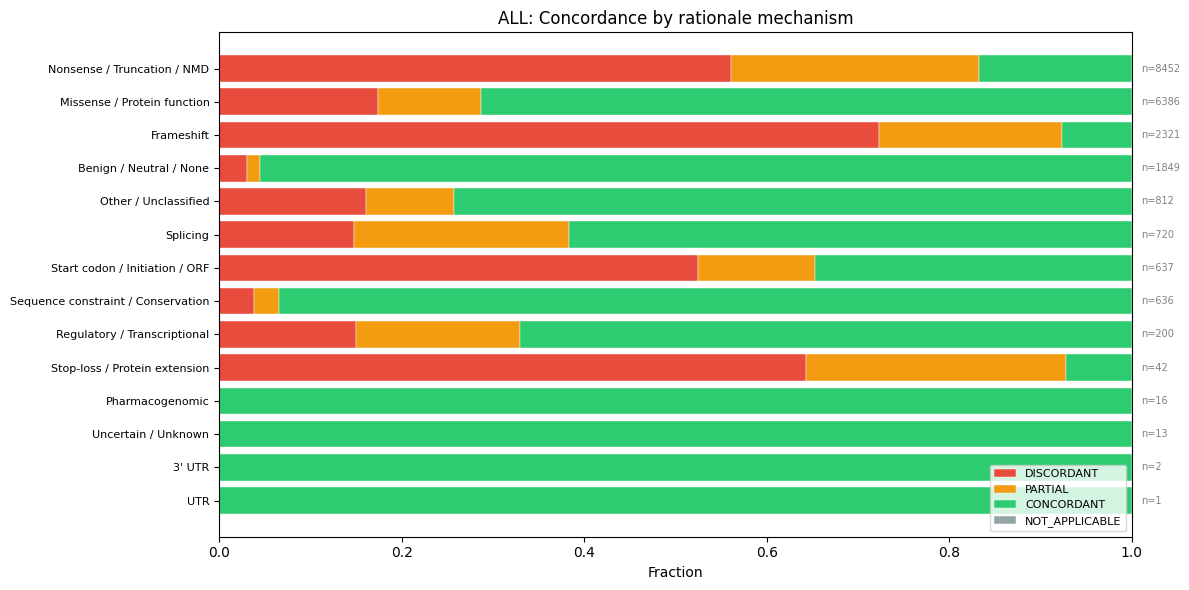

In [ ]:
def plot_concordance_by_mechanism(
    df, mechanism_col="rationale_mechanism", concord_col="concordance",
    conc_order=DEFAULT_CONC_ORDER, conc_colors=CONC_COLORS,
    top_k=15, figsize=(12, 6), title=None,
):
    d = df.copy()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()
    ct = pd.crosstab(d[mechanism_col], d[concord_col], dropna=False)
    for c in conc_order:
        if c not in ct.columns: ct[c] = 0
    ct = ct[conc_order]
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    if top_k and len(ct) > top_k: ct = ct.head(top_k)

    denom = ct.sum(axis=1).replace(0, np.nan)
    frac = ct.div(denom, axis=0).fillna(0)
    totals = ct.sum(axis=1)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(frac)); left = np.zeros(len(frac))
    frac_rev = frac.iloc[::-1]; totals_rev = totals.iloc[::-1]

    for c in conc_order:
        if c not in frac_rev.columns: continue
        vals = frac_rev[c].values
        ax.barh(y, vals, left=left, label=c,
                color=conc_colors.get(c), edgecolor="white", linewidth=0.3)
        left += vals

    ax.set_yticks(y); ax.set_yticklabels(frac_rev.index, fontsize=8)
    ax.set_xlabel("Fraction"); ax.set_xlim(0, 1)
    for i, n in enumerate(totals_rev.values):
        ax.text(1.01, i, f"n={int(n)}", va="center", ha="left",
                fontsize=7, color="grey")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_title(title or f"Concordance breakdown per {mechanism_col}")
    fig.tight_layout()
    return fig, ax, frac


# ── Single representative call: ALL, rationale mechanism ─────────────
# mechanism_col options: "rationale_mechanism", "primary_signal_mechanism"
# top_k options: 10, 15, 20 — controls how many rows
fig, ax, df_out = plot_concordance_by_mechanism(
    merged,
    mechanism_col="rationale_mechanism",    # try: "primary_signal_mechanism"
    top_k=15,                               # try: 10, 20
    title="ALL: Concordance by rationale mechanism",
)
plt.show()


# # ── Full loop: both mechanism types ──────────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     base = REPORT_DIR / subset_name / "6_concordance_by_mechanism"
#     for mech_type, mech_col in [("rationale", "rationale_mechanism"),
#                                  ("primary",  "primary_signal_mechanism")]:
#         fig, ax, df_out = plot_concordance_by_mechanism(
#             dsub, mechanism_col=mech_col,
#             title=f"{subset_name}: Concordance by {mech_type} mechanism")
#         _savefig(fig, base / f"concordance_by_{mech_type}_mechanism.{FMT}")
#         _savedf(df_out, base / f"concordance_by_{mech_type}_mechanism.csv")
#         plt.show()

---
## Plot 7: Score Correlation Heatmap (Spearman ρ vs LLR)

Rows = conservation/functional scores. Columns = data subsets. Cell = Spearman ρ(score, LLR) within that subset.

**Parameters to vary:**
- `reference_col`: which score to correlate against (default `"LLR"` = NT delta)
- `stratify_concordance`: `False` → columns = ALL + signal levels; `True` → signal × concordance (finer grid)
- `score_cols`: which scores to include as rows (from `DEFAULT_SCORE_COLS`)
- `cmap`: colormap (default `"RdBu_r"`)

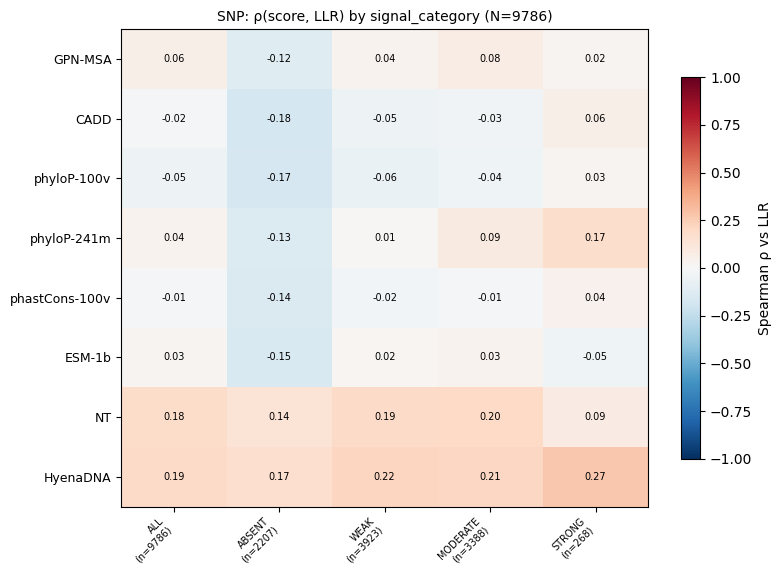

In [ ]:
def plot_score_correlation_heatmap(
    df, reference_col="LLR", score_cols=DEFAULT_SCORE_COLS,
    signal_col="signal_category", concord_col="concordance",
    signal_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    stratify_concordance=False, figsize=None, title=None, cmap="RdBu_r",
):
    d = df.copy()
    d[signal_col]  = d[signal_col].astype(str).str.strip().str.upper()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()

    other = [c for c in score_cols if c in d.columns and c != reference_col]
    if reference_col not in d.columns or not other:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5,
                f"Missing '{reference_col}'" if reference_col not in d.columns
                else "No other score columns",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=12, color="grey")
        ax.set_title(title or "Score correlation")
        return fig, ax, pd.DataFrame()

    def _corr(sub):
        out = {}
        for sc in other:
            vals = sub[[reference_col, sc]].dropna()
            out[sc] = _spearman_rho(vals[reference_col].values,
                                    vals[sc].values) if len(vals) >= 3 else np.nan
        return pd.Series(out)

    cols = []
    if stratify_concordance:
        for sig in signal_order:
            for conc in conc_order:
                mask = (d[signal_col]==sig) & (d[concord_col]==conc)
                n = int(mask.sum())
                cols.append((_corr(d.loc[mask]), f"{sig}\n{conc}\n(n={n})"))
    else:
        cols.append((_corr(d), f"ALL\n(n={len(d)})"))
        for sig in signal_order:
            mask = d[signal_col] == sig; n = int(mask.sum())
            cols.append((_corr(d.loc[mask]), f"{sig}\n(n={n})"))

    corr_df = pd.DataFrame({lab: s for s, lab in cols})
    nr, nc = corr_df.shape
    if figsize is None:
        figsize = (max(8, nc*1.3), max(4, nr*0.55+1.5))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr_df.to_numpy(), aspect="auto", cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8, label=f"Spearman ρ vs {reference_col}")
    ax.set_xticks(np.arange(nc))
    ax.set_xticklabels(corr_df.columns,
                       rotation=90 if stratify_concordance else 45,
                       ha="right", fontsize=7)
    ax.set_yticks(np.arange(nr)); ax.set_yticklabels(corr_df.index, fontsize=9)
    for i in range(nr):
        for j in range(nc):
            v = corr_df.iloc[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(v)>0.5 else "black")
    if title is None:
        strat = "signal_category×Concordance" if stratify_concordance else "signal_category"
        title = f"Spearman ρ(score, {reference_col}) by {strat}"
    ax.set_title(title, fontsize=10); fig.tight_layout()
    return fig, ax, corr_df


# ── Single representative call: SNP, unstratified ────────────────────
# stratify_concordance options: False (compact), True (full signal×conc grid)
# reference_col options: "LLR" (default), or any score in DEFAULT_SCORE_COLS
# score_cols: filter to available subset of DEFAULT_SCORE_COLS
sc_avail = [c for c in DEFAULT_SCORE_COLS if c in merged.columns]
dsub_snp = merged.loc[SUBSETS["SNP"](merged)].copy()
fig, ax, df_out = plot_score_correlation_heatmap(
    dsub_snp,
    reference_col="LLR",                          # try: "CADD", "phyloP-100v"
    score_cols=sc_avail,
    stratify_concordance=False,                    # try: True
    title=f"SNP: ρ(score, LLR) by signal_category (N={len(dsub_snp)})",
)
plt.show()


# # ── Full loop: unstratified + stratified ─────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     sc_avail = [c for c in DEFAULT_SCORE_COLS if c in dsub.columns]
#     if not sc_avail: continue
#     base = REPORT_DIR / subset_name / "7_score_comparison"

#     # 7a: by signal_category only
#     fig, ax, df_out = plot_score_correlation_heatmap(
#         dsub, score_cols=sc_avail, stratify_concordance=False,
#         title=f"{subset_name}: ρ(score, LLR) by signal_category (N={len(dsub)})")
#     _savefig(fig, base / f"corr_vs_LLR_by_mlm.{FMT}")
#     _savedf(df_out, base / "corr_vs_LLR_by_mlm.csv")
#     plt.show()

#     # 7b: by signal_category × concordance
#     fig, ax, df_out = plot_score_correlation_heatmap(
#         dsub, score_cols=sc_avail, stratify_concordance=True,
#         title=f"{subset_name}: ρ(score, LLR) by signal×conc (N={len(dsub)})")
#     _savefig(fig, base / f"corr_vs_LLR_by_mlm_x_concordance.{FMT}")
#     _savedf(df_out, base / "corr_vs_LLR_by_mlm_x_concordance.csv")
#     plt.show()

---
## Plot 8: Median Score Comparison Heatmap (z-scored)

Rows = score names, columns = data subsets. Cell color = z-scored aggregate, cell text = raw aggregate. Shows which scores are relatively elevated/depressed across strength bins.

**Parameters to vary:**
- `agg`: `"median"` (default, robust) or `"mean"`
- `stratify_concordance`: `False` → columns = ALL + signal levels; `True` → signal × concordance
- `center_zero`: `True` → symmetric diverging colormap around 0
- `cmap`: `"RdBu_r"` (default)

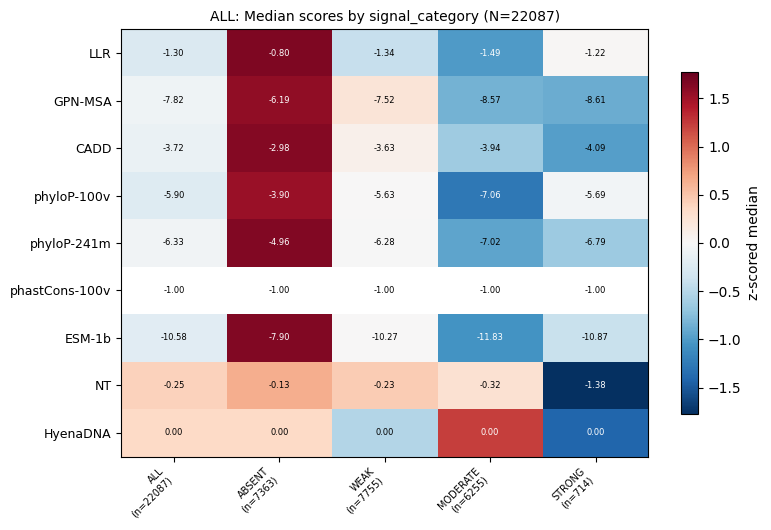

In [ ]:
def plot_score_median_heatmap(
    df, score_cols=DEFAULT_SCORE_COLS,
    signal_col="signal_category", concord_col="concordance",
    signal_order=DEFAULT_ORDER, conc_order=DEFAULT_CONC_ORDER,
    agg="median", stratify_concordance=False,
    figsize=None, title=None, cmap="RdBu_r", center_zero=True,
):
    d = df.copy()
    d[signal_col]  = d[signal_col].astype(str).str.strip().str.upper()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()
    available = [c for c in score_cols if c in d.columns]
    if not available:
        fig, ax = plt.subplots(figsize=(6,4))
        ax.text(0.5, 0.5, "No score columns found", transform=ax.transAxes,
                ha="center", va="center", fontsize=12, color="grey")
        return fig, ax, pd.DataFrame()

    groups = []
    if stratify_concordance:
        for sig in signal_order:
            for conc in conc_order:
                mask = (d[signal_col]==sig) & (d[concord_col]==conc)
                sub = d.loc[mask, available]; n = int(mask.sum())
                row = sub.median() if agg=="median" else sub.mean()
                row.name = f"{sig}\n{conc}\n(n={n})"; groups.append(row)
    else:
        row_all = (d[available].median() if agg=="median" else d[available].mean())
        row_all.name = f"ALL\n(n={len(d)})"; groups.append(row_all)
        for sig in signal_order:
            mask = d[signal_col]==sig
            sub = d.loc[mask, available]; n = int(mask.sum())
            row = sub.median() if agg=="median" else sub.mean()
            row.name = f"{sig}\n(n={n})"; groups.append(row)

    val_df = pd.DataFrame(groups).T
    rmean = val_df.mean(axis=1); rstd = val_df.std(axis=1).replace(0, np.nan)
    val_z = val_df.sub(rmean, axis=0).div(rstd, axis=0)
    nr, nc = val_z.shape
    if figsize is None:
        figsize = (max(8, nc*1.2), max(4, nr*0.6))

    fig, ax = plt.subplots(figsize=figsize)
    vmin = vmax = None
    if center_zero:
        am = np.nanmax(np.abs(val_z.values)); vmin, vmax = -am, am
    im = ax.imshow(val_z.to_numpy(), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8, label=f"z-scored {agg}")
    ax.set_xticks(np.arange(nc))
    ax.set_xticklabels(val_z.columns,
                       rotation=90 if stratify_concordance else 45,
                       ha="right", fontsize=7)
    ax.set_yticks(np.arange(nr)); ax.set_yticklabels(val_z.index, fontsize=9)
    for i in range(nr):
        for j in range(nc):
            raw = val_df.iloc[i,j]; z = val_z.iloc[i,j]
            if np.isfinite(raw):
                ax.text(j, i, f"{raw:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if abs(z)>1.0 else "black")
    if title is None:
        strat = "signal_category×Concordance" if stratify_concordance else "signal_category"
        title = f"Score comparison ({agg}, z-scored) by {strat}"
    ax.set_title(title, fontsize=10); fig.tight_layout()
    return fig, ax, val_df


# ── Single representative call: ALL, median, unstratified ────────────
# agg options: "median" (default, robust), "mean"
# stratify_concordance options: False (compact), True (full grid)
# center_zero options: True (symmetric diverging), False (data range)
sc_avail = [c for c in DEFAULT_SCORE_COLS if c in merged.columns]
fig, ax, df_out = plot_score_median_heatmap(
    merged,
    score_cols=sc_avail,
    agg="median",                       # try: "mean"
    stratify_concordance=False,         # try: True
    title=f"ALL: Median scores by signal_category (N={len(merged)})",
)
plt.show()


# # ── Full loop ────────────────────────────────────────────────────────
# for subset_name, sel_fn in SUBSETS.items():
#     dsub = merged.loc[sel_fn(merged)].copy()
#     sc_avail = [c for c in DEFAULT_SCORE_COLS if c in dsub.columns]
#     if not sc_avail: continue
#     base = REPORT_DIR / subset_name / "7_score_comparison"
#     fig, ax, df_out = plot_score_median_heatmap(
#         dsub, score_cols=sc_avail,
#         title=f"{subset_name}: Median scores by signal_category (N={len(dsub)})")
#     _savefig(fig, base / f"median_scores_by_mlm.{FMT}")
#     _savedf(df_out, base / "median_scores_by_mlm.csv")
#     plt.show()

---
## Stats Tables: Association Strengths & Mechanism Breakdowns

No plots — just numeric summaries saved to CSV.

- **association_strengths**: Spearman ρ (ordinal) + Cramér's V + crosstab for signal × MLM
- **mechanism_stats**: mechanism frequency tables stratified by concordance (and optionally strength bins)
- **rationale_vs_concordance_counts**: raw crosstab of rationale mechanism × concordance level

In [ ]:
def association_strengths(df, signal_col="signal_category",
                          mlm_col="MLM_category",
                          signal_order=DEFAULT_ORDER,
                          mlm_order=DEFAULT_ORDER):
    d = df.copy()
    for col in [signal_col, mlm_col]:
        d[col] = d[col].astype("string").str.strip().str.upper()
    s = _ordinal_encode(d[signal_col], signal_order)
    m = _ordinal_encode(d[mlm_col], mlm_order)
    mask = s.notna() & m.notna()
    ct = _safe_crosstab(d.loc[mask, signal_col], d.loc[mask, mlm_col],
                        signal_order, mlm_order)
    return {
        "n": int(mask.sum()),
        "spearman_rho_ordinal": _spearman_rho(s[mask].to_numpy(),
                                               m[mask].to_numpy()),
        "cramers_v": _cramers_v_from_crosstab(ct),
        "crosstab": ct,
    }

def mechanism_stats(df, mechanism_col="rationale_mechanism",
                    by=None, top_k=15, normalize="row"):
    if by is None: by = ["concordance"]
    g = df.groupby(by, observed=False)[mechanism_col].value_counts(dropna=False)
    out = g.unstack(mechanism_col, fill_value=0)
    if top_k and out.shape[1] > top_k:
        keep = df[mechanism_col].value_counts(dropna=False).head(top_k).index
        out = out.loc[:, out.columns.intersection(keep)]
    if normalize == "row":
        out = out.div(out.sum(axis=1).replace(0, np.nan), axis=0)
    return out


# ── Single representative call: ALL, overall association ─────────────
# by options for mechanism_stats:
#   ["concordance"] — one row per concordance level
#   ["concordance", "signal_category", "MLM_category"] — full stratification
# normalize options: "row" (fraction per row), None (raw counts)
# top_k options: 10, 15, 20
assoc = association_strengths(merged)
print(f"Overall association: ρ={assoc['spearman_rho_ordinal']:.3f}, "
      f"V={assoc['cramers_v']:.3f}, n={assoc['n']}")
print(assoc["crosstab"])


# ── Full loop ────────────────────────────────────────────────────────
for subset_name, sel_fn in SUBSETS.items():
    dsub = merged.loc[sel_fn(merged)].copy()
    base = REPORT_DIR / subset_name / "tables"

    # Overall association
    _savedf(association_strengths(dsub),
            base / "strength_association_overall.csv")

    # Per-concordance association
    for c in DEFAULT_CONC_ORDER:
        d_c = dsub[dsub["concordance"].astype(str).str.strip().str.upper() == c]
        if len(d_c) > 0:
            _savedf(association_strengths(d_c),
                    base / f"strength_association_{c}.csv")

    # Mechanism breakdowns
    _savedf(mechanism_stats(dsub, "rationale_mechanism",
                            by=["concordance"], top_k=20),
            base / "rationale_mechanism_by_conc.csv")
    _savedf(mechanism_stats(dsub, "rationale_mechanism",
                            by=["concordance","signal_category","MLM_category"],
                            top_k=20),
            base / "rationale_mechanism_by_conc_and_strength.csv")
    _savedf(mechanism_stats(dsub, "primary_signal_mechanism",
                            by=["concordance","signal_category","MLM_category"],
                            top_k=20),
            base / "primary_mechanism_by_conc_and_strength.csv")

    # Rationale × concordance raw counts
    _savedf(_safe_crosstab(
        dsub["rationale_mechanism"], dsub["concordance"],
        row_order=sorted(dsub["rationale_mechanism"].dropna().unique()),
        col_order=DEFAULT_CONC_ORDER),
        base / "rationale_vs_concordance_counts.csv")

print("All stats tables saved.")